<a href="https://colab.research.google.com/github/dawg-at-irya/BayesFactor/blob/main/BayesFactor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# A modified version of the discussion by Andy Casey
# here: https://astrowizici.st/teaching/phs5000/6/
!pip install pymc
!pip install corner
!pip install arviz
!pip install scipy
import pymc as pm
from pymc.smc.kernels import MH
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import corner
import arviz as az
from scipy.special import logsumexp

In [6]:
def get_Hoggetal2010_data():
    """
    Load the Hogg et al. 2010 dataset and return the last 15 points
    """
    X = np.array([201, 244, 47, 287, 203, 58, 210, 202, 198, 158, 165, 201,
                  157, 131, 166, 160, 186, 125, 218, 146], dtype=float)
    Y = np.array([592, 401, 583, 402, 495, 173, 479, 504, 510, 416, 393, 442,
                  317, 311, 400, 337, 423, 334, 533, 344], dtype=float)
    sigma_Y = np.array([61, 25, 38, 15, 21, 15, 27, 14, 30, 16, 14, 25, 52,
                        16, 34, 31, 42, 26, 16, 22], dtype=float)
    # sigma_X = np.array([9, 4, 11, 7, 5, 9, 4, 4, 11, 7, 5, 5, 5, 6, 6, 5,
    #                     9, 8, 6, 5], dtype=float)
    # rho_XY = np.array([-0.84, 0.31, 0.64, -0.27, -0.33, 0.67, -0.02, -0.05,
    #                    -0.84, -0.69, 0.30, -0.46, -0.03, 0.50, 0.73, -0.52,
    #                    0.90, 0.40, -0.78, -0.56], dtype=float)
    return X[5:], Y[5:], sigma_Y[5:], None, None


def scatterplot(x, y, y_err, y_true=None):
    """
    Compare the data to the true model on a scatter plot
    Parameters:
        x, y, y_err: data and uncertainties
        y_true: true model values
    """
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(x, y, c="k", s=10)
    if y_err is not None:
        ax.errorbar(x, y, yerr=y_err, fmt="o", lw=1, c="k", label='Data')
    if y_true is not None:
        ax.plot(x, y_true, c="k", lw=2, label="Truth")

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_xlim(0, 100)
    ax.set_ylim(-5, 20)
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    fig.tight_layout()
    return (fig, ax)


def simulate_data(Hogg=True):
    """
    Load data from Hogg et al. 2010 or generate data as on Andy Casey's page.
    Parameters:
        Hogg: True if Hogg et al. 2010 data should be used, False otherwise
    """
    if Hogg:
        return get_Hoggetal2010_data()
    np.random.seed(1)
    # Some MAGIC numbers
    N = 20
    x_scale = 100
    y_err_intrinsic = 1.75
    theta_scales = np.logspace(-3, 1, 3)
    # theta_scales = theta_scales[::-1]  # reverse order

    theta = theta_scales * np.random.uniform(size=3)
    # theta = theta[::-1]  # reverse order
    print(theta)

    x = x_scale * np.random.uniform(size=N)
    x = np.sort(x)
    y_true = np.polyval(theta, x)

    # Add noise in the y-direction.
    y_err = y_err_intrinsic * np.random.randn(N)
    y = y_true + np.random.randn(N) * y_err
    y_err = np.abs(y_err)

    fig, ax = scatterplot(x, y, y_err, y_true)

    return x, y, y_err, y_true, theta


def model_1_smc(x, y, y_err, Hogg=True):
    """
    Fit a linear model to the data using sequential Monte Carlo (SMC).
    Parameters:
        x, y, y_err: data and uncertainties
        Hogg: True if Hogg et al. 2010 data should be used, False otherwise
    """
    np.random.seed(1)
    with pm.Model() as line_model:
        if not Hogg:
            theta_0 = pm.Normal('theta0', mu=0, sigma=10)
            theta_1 = pm.Normal('theta1', mu=0, sigma=10)
        else:
            theta_0 = pm.Normal('theta0', mu=35, sigma=100)
            theta_1 = pm.Normal('theta1', mu=2.5, sigma=100)

        mu = theta_0 + theta_1 * x
        pm.Normal('y', mu=mu, sigma=y_err, observed=y)

        trace = pm.sample_smc(draws=10000, cores=6)
    return trace, line_model


def model_2_smc(x, y, y_err, Hogg=True):
    """
    Fit a quadratic model to the data using sequential Monte Carlo (SMC).
    Parameters:
        x, y, y_err: data and uncertainties
        Hogg: True if Hogg et al. 2010 data should be used, False otherwise
    """
    np.random.seed(1)
    with pm.Model() as poly_model:
        if not Hogg:
            theta_0 = pm.Normal('theta0', mu=0, sigma=10)
            theta_1 = pm.Normal('theta1', mu=0, sigma=10)
            theta_2 = pm.Normal('theta2', mu=0, sigma=10)
        else:
            theta_0 = pm.Normal('theta0', mu=75, sigma=100)
            theta_1 = pm.Normal('theta1', mu=1.5, sigma=100)
            theta_2 = pm.Normal('theta2', mu=1e-3, sigma=10)

        mu = theta_0 + theta_1 * x + theta_2 * x**2
        pm.Normal('y', mu=mu, sigma=y_err, observed=y)

        trace = pm.sample_smc(draws=10000, cores=6, kernel=MH,
                              # kernel_kwargs={"allow_singular": True})
                              correlation_threshold=0.05,)
    return trace, poly_model


def plot_posterior_samples(x, y, y_err, xi, posterior, model='linear',
                           n_samples=100):
    """
    Plot posterior predictive samples over the data.
    Parameters:
        x, y, y_err: data and uncertainties
        xi: points to evaluate model on
        posterior: stacked posterior from InferenceData
        model: 'linear' or 'quadratic'
        n_samples: number of posterior samples to plot
    """
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(x, y, yerr=y_err, fmt="o", color="k", label="data")

    idxs = np.random.choice(posterior.sample.size, size=n_samples,
                            replace=False)
    for idx in idxs:
        if model == 'linear':
            theta0 = posterior["theta0"].values[idx]
            theta1 = posterior["theta1"].values[idx]
            y_pred = theta0 + theta1 * xi
        elif model == 'quadratic':
            theta0 = posterior["theta0"].values[idx]
            theta1 = posterior["theta1"].values[idx]
            theta2 = posterior["theta2"].values[idx]
            y_pred = theta0 + theta1 * xi + theta2 * xi**2
        else:
            raise ValueError("Model must be 'linear' or 'quadratic'")
        ax.plot(xi, y_pred, alpha=0.1, color="C1" if model == 'quadratic'
                else "C0")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    return fig, ax


def main(Hogg=False):
    """
    Main function to run the simulation.
    Parameters:
        Hogg: True if Hogg et al. 2010 data should be used, False otherwise
    Returns:
        Z: list of log(Z) values for each model
    """
    np.random.seed(1)

    x, y, y_err, y_true, theta_true = simulate_data(Hogg=Hogg)
    trace1, model1 = model_1_smc(x, y, y_err, Hogg=Hogg)
    trace2, model2 = model_2_smc(x, y, y_err, Hogg=Hogg)

    xi = np.linspace(x.min(), x.max(), 500)

    posterior1 = trace1.posterior.stack(sample=("chain", "draw"))
    plot_posterior_samples(x, y, y_err, xi, posterior1, model='linear')
    samples1 = np.vstack([posterior1["theta0"].values,
                          posterior1["theta1"].values]).T

    fig1 = corner.corner(samples1, labels=["$\\theta_0$", "$\\theta_1$"],
                         show_titles=True, title_fmt=".2f")
    fig1.suptitle("Posterior samples for linear model", fontsize=16)

    posterior2 = trace2.posterior.stack(sample=("chain", "draw"))
    plot_posterior_samples(x, y, y_err, xi, posterior2, model='quadratic')

    samples2 = np.vstack([posterior2["theta0"].values,
                          posterior2["theta1"].values,
                          posterior2["theta2"].values]).T

    fig2 = corner.corner(samples2,
                         labels=["$\\theta_0$", "$\\theta_1$", "$\\theta_2$"],
                         show_titles=True, title_fmt=".2f")
    fig2.suptitle("Posterior samples for quadratic model", fontsize=16)

    Z = []
    for trace in [trace1, trace2]:
        logml_da = trace.sample_stats["log_marginal_likelihood"]
        logml_final = []
        for i in range(logml_da.sizes["chain"]):
            vals = logml_da.sel(chain=i).values
            flat = np.ravel(vals).flatten()
            for v in flat:
                try:
                    v_float = float(np.ravel(v)[0]) if isinstance(
                            v, (list, np.ndarray)) else float(v)
                except Exception:
                    continue
                if np.isfinite(v_float):
                    logml_final.append(v_float)
        if len(logml_final) < logml_da.sizes["chain"]:
            raise ValueError("Failed to extract one logZ per chain.")
        logml_final = np.array(logml_final)
        # # Safely extract the final logZ value from each chain
        # logml_final = np.array([
        #     float(logml_da.sel(chain=i).values[-1]) for i in
        #     range(logml_da.sizes["chain"])
        # ])
        # # Option 1: arithmetic mean of the logZ estimates from each chain
        # Z = np.mean(logml_final)
        # Option 2: marginal likelihood from all chains (more stable numerically)
        Z_logsumexp = logsumexp(logml_final) - np.log(len(logml_final))
        Z.append(Z_logsumexp)
    return Z

Output()

Generating fit for data from Hogg et al. 2010



Output()

Output()



log(Z_linear)     = -80.06
log(Z_quadratic)  = -88.07
Bayes factor (linear / quadratic) = 2999.79


Generating fit for data generated by Andy Casey

[0.00041702 0.07203245 0.00114375]


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details




log(Z_linear)     = -42.64
log(Z_quadratic)  = -47.42
Bayes factor (linear / quadratic) = 118.94


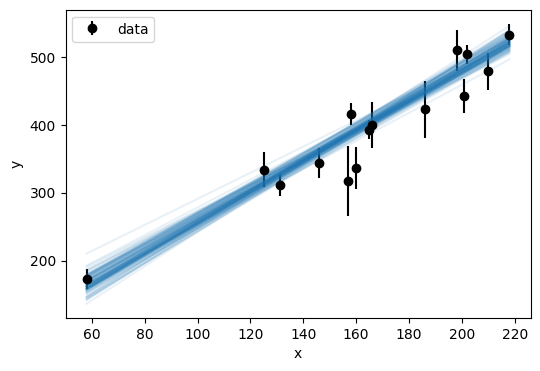

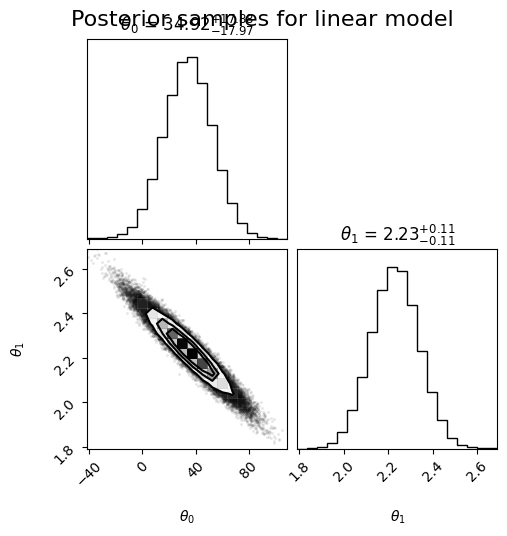

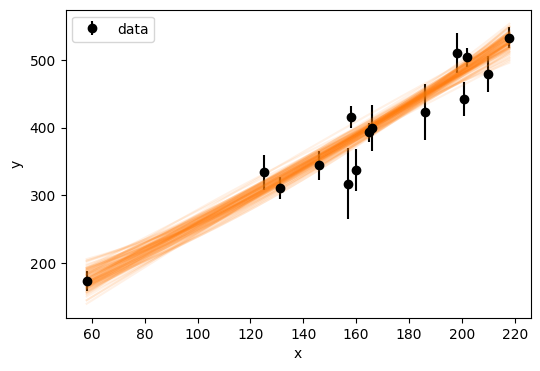

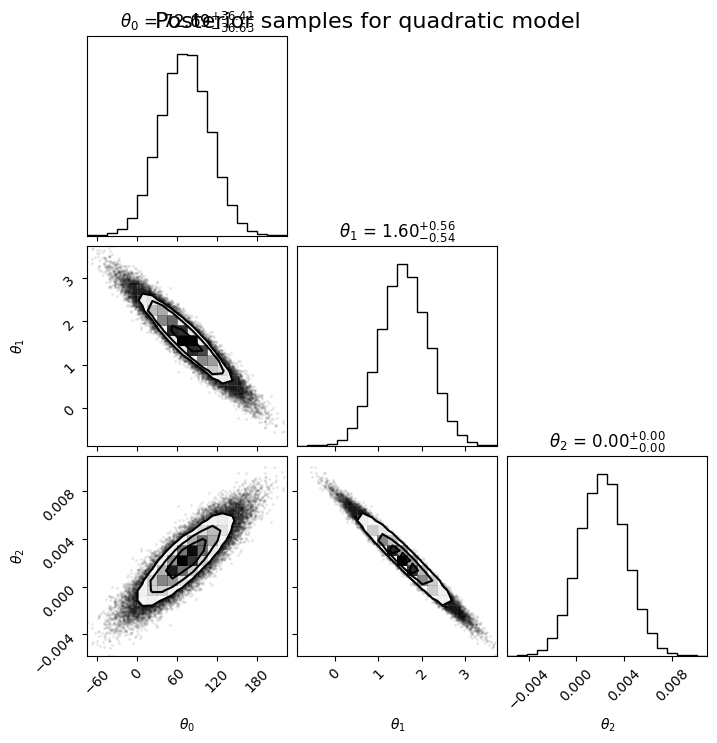

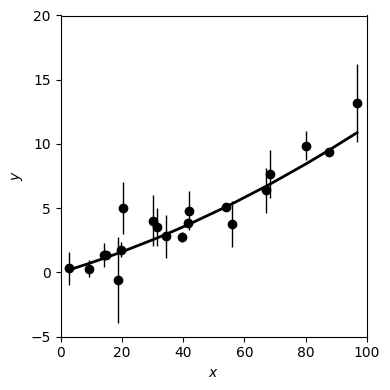

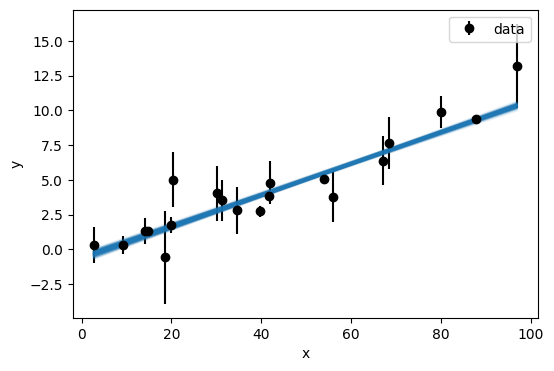

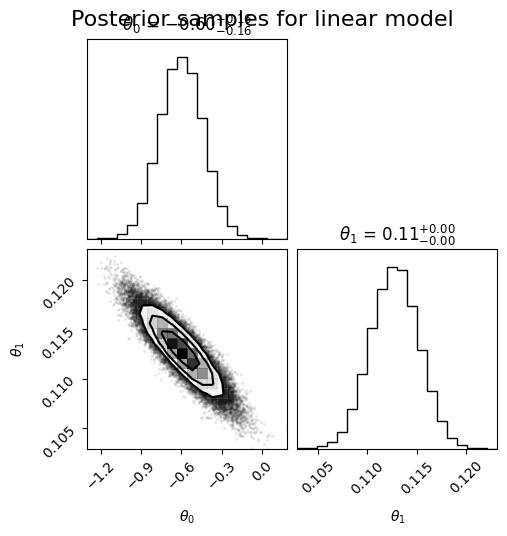

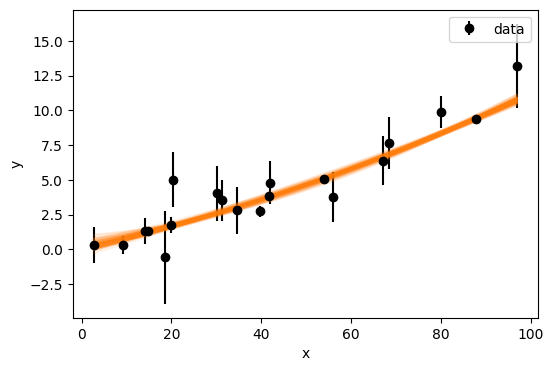

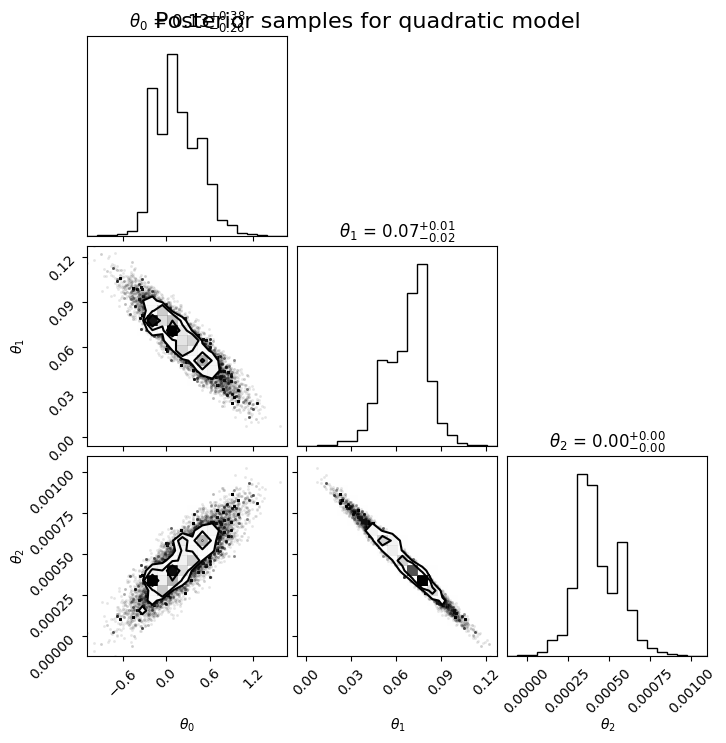

In [10]:
if __name__ == "__main__":
    import multiprocessing as mp
    mp.set_start_method("spawn", force=True)
    print("Generating fit for data from Hogg et al. 2010")
    print()
    Z = main(Hogg=True)
    print()
    print()
    print(f"log(Z_linear)     = {Z[0]:.2f}")
    print(f"log(Z_quadratic)  = {Z[1]:.2f}")
    if Z[1] > Z[0]:
        BF = np.exp(Z[1] - Z[0])
        sense = "quadratic / linear"
    else:
        BF = np.exp(Z[0] - Z[1])
        sense = "linear / quadratic"
    print(f"Bayes factor ({sense}) = {BF:.2f}")
    print()
    print()
    print("Generating fit for data generated by Andy Casey")
    print()
    Z = main(Hogg=False)
    print()
    print()
    print(f"log(Z_linear)     = {Z[0]:.2f}")
    print(f"log(Z_quadratic)  = {Z[1]:.2f}")
    if Z[1] > Z[0]:
        BF = np.exp(Z[1] - Z[0])
        sense = "quadratic / linear"
    else:
        BF = np.exp(Z[0] - Z[1])
        sense = "linear / quadratic"
    print(f"Bayes factor ({sense}) = {BF:.2f}")
